# galerie — beau_graphique

Démo visuelle exécutable de tous les modules : `beau_graphique`, `narratif`, `pipeline`, `themes`.
Données réalistes (contexte Cameroun / FCFA) pour juger rapidement si la librairie correspond au besoin.

Exécuter cellule par cellule (Kernel → Restart & Run All pour tout regénérer).

## 0. Setup

In [76]:
from beau_graphique import (
    init, ligne, barres, barres_groupees, aire, histogramme,
    nuage, camembert, heatmap, dashboard,
    dot_plot_comparatif, bulle_4d, unit_chart,
    box_plot, violin, waterfall, lollipop, slope, facet,
)
from narratif import (
    barres_focus, ligne_focus, comparaison_avant_apres, barres_ranked,
    divergent, bullet_chart, barres_connectees, palette_focus, ACCENTS,
    annoter_zone, annoter_seuil, annoter_delta, annoter_point,
)
from pipeline import inspecter, nettoyer, depuis_df, barres_df, ligne_df, nuage_df, histogramme_df
from themes import appliquer, lister, apercu, depuis_couleur, palette_safe, reinitialiser

import numpy as np
import pandas as pd
import datetime
import matplotlib.pyplot as plt

init()
np.random.seed(42)


✓ Style beau_graphique activé.


## 1. Données d'exemple

Un jeu de données mensuel (ventes FCFA, marges, régions) qui sert de fil rouge à toute la galerie.

In [78]:
mois = ["Jan", "Fév", "Mar", "Avr", "Mai", "Jun", "Jul", "Aoû", "Sep", "Oct", "Nov", "Déc"]
dates_mensuelles = pd.date_range("2024-01-01", periods=12, freq="MS")

ventes_douala = [42, 48, 51, 55, 58, 62, 60, 65, 71, 68, 74, 79]
ventes_yaounde = [30, 35, 38, 42, 41, 45, 48, 50, 53, 55, 58, 61]

df = pd.DataFrame({
    "Mois": mois,
    "Date": dates_mensuelles,
    "Ventes_Douala": ventes_douala,
    "Ventes_Yaounde": ventes_yaounde,
    "Region": np.random.choice(["Littoral", "Centre", "Ouest"], size=12),
    "Marge_pct": np.random.normal(22, 4, 12).round(1),
})
df.head()


,Mois,Date,Ventes_Douala,Ventes_Yaounde,Region,Marge_pct
0,Jan,2024-01-01,42,30,Ouest,23.1
1,Fév,2024-02-01,48,35,Littoral,26.0
2,Mar,2024-03-01,51,38,Ouest,19.7
3,Avr,2024-04-01,55,42,Ouest,19.9
4,Mai,2024-05-01,58,41,Littoral,19.7


## 2. `beau_graphique.py` — graphiques de base

### `ligne()`

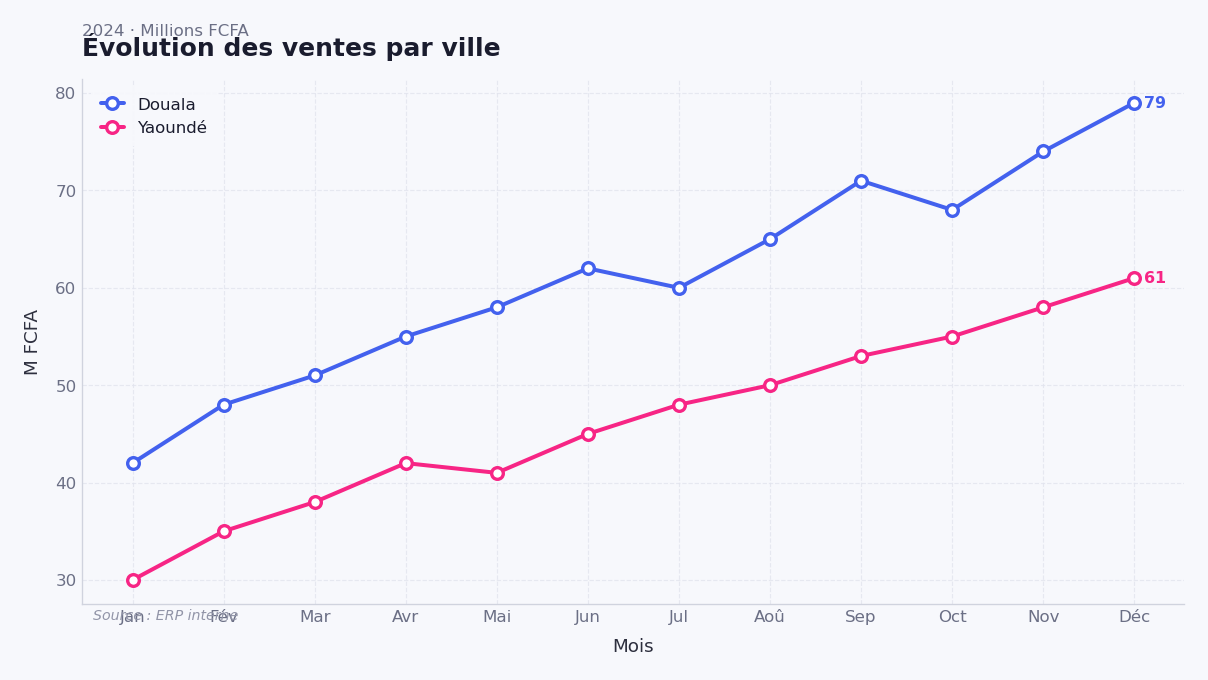

In [82]:
ligne(
    x=mois,
    y_series={"Douala": ventes_douala, "Yaoundé": ventes_yaounde},
    titre="Évolution des ventes par ville",
    sous_titre="2024 · Millions FCFA",
    xlabel="Mois", ylabel="M FCFA",
    note="Source : ERP interne",
)
plt.show()


### `barres()`

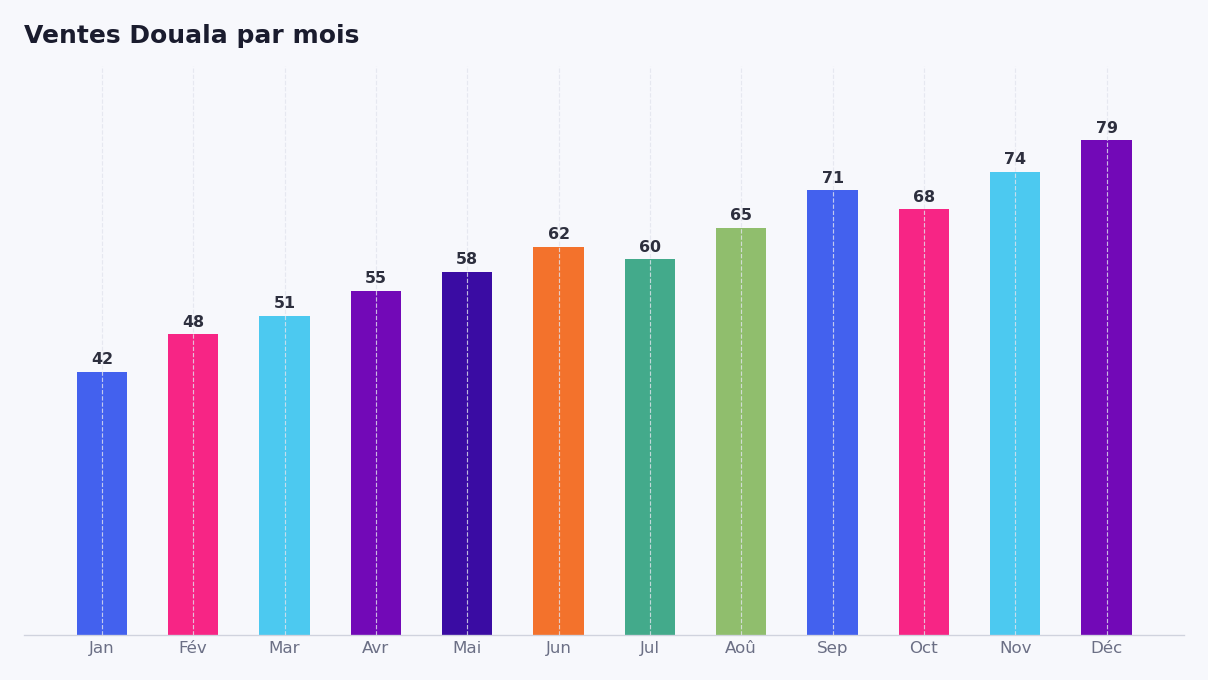

In [85]:
barres(
    categories=mois,
    valeurs=ventes_douala,
    titre="Ventes Douala par mois",
    ylabel="M FCFA",
    couleurs_multiples=True,
)
plt.show()


### `barres_groupees()`

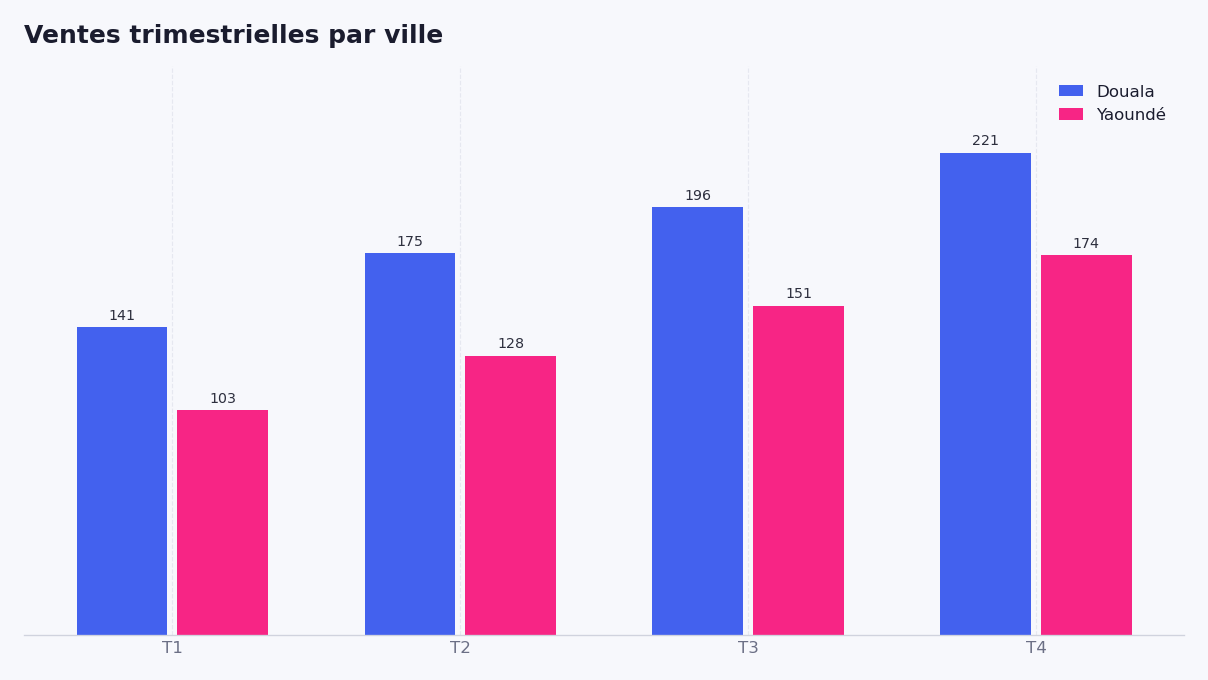

In [88]:
barres_groupees(
    categories=["T1", "T2", "T3", "T4"],
    groupes={
        "Douala": [141, 175, 196, 221],
        "Yaoundé": [103, 128, 151, 174],
    },
    titre="Ventes trimestrielles par ville",
    ylabel="M FCFA",
)
plt.show()


### `aire()`

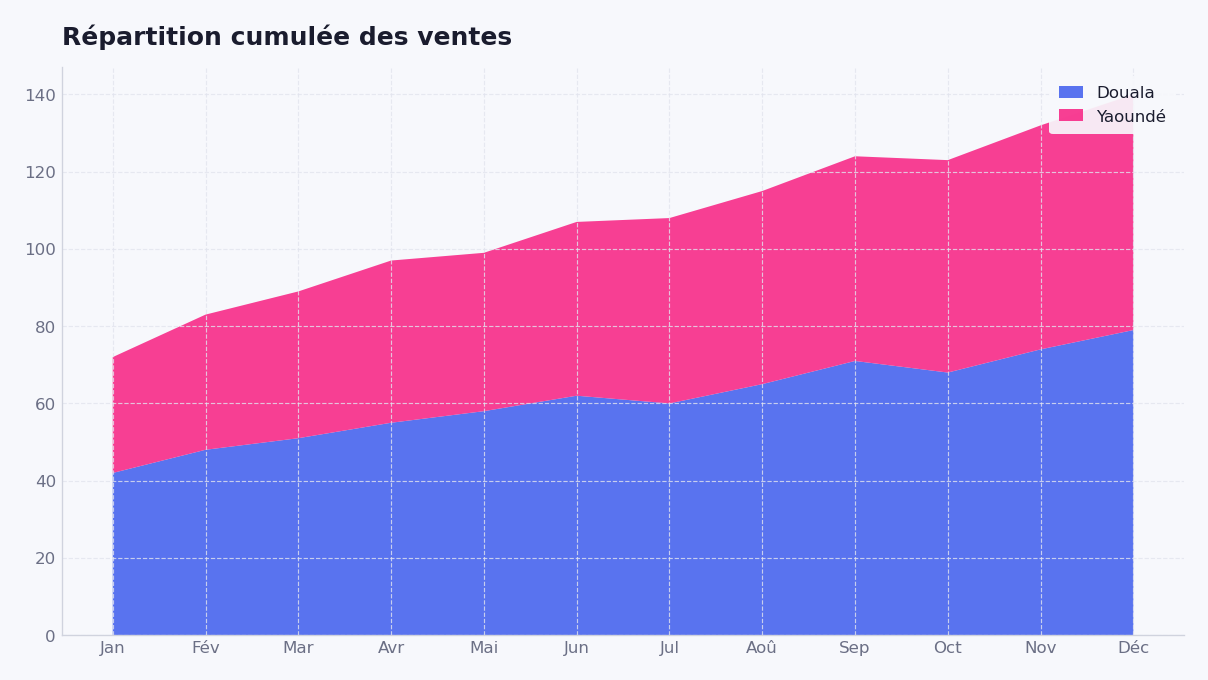

In [90]:
aire(
    x=mois,
    y_series={"Douala": ventes_douala, "Yaoundé": ventes_yaounde},
    titre="Répartition cumulée des ventes",
    empile=True,
)
plt.show()


### `histogramme()`

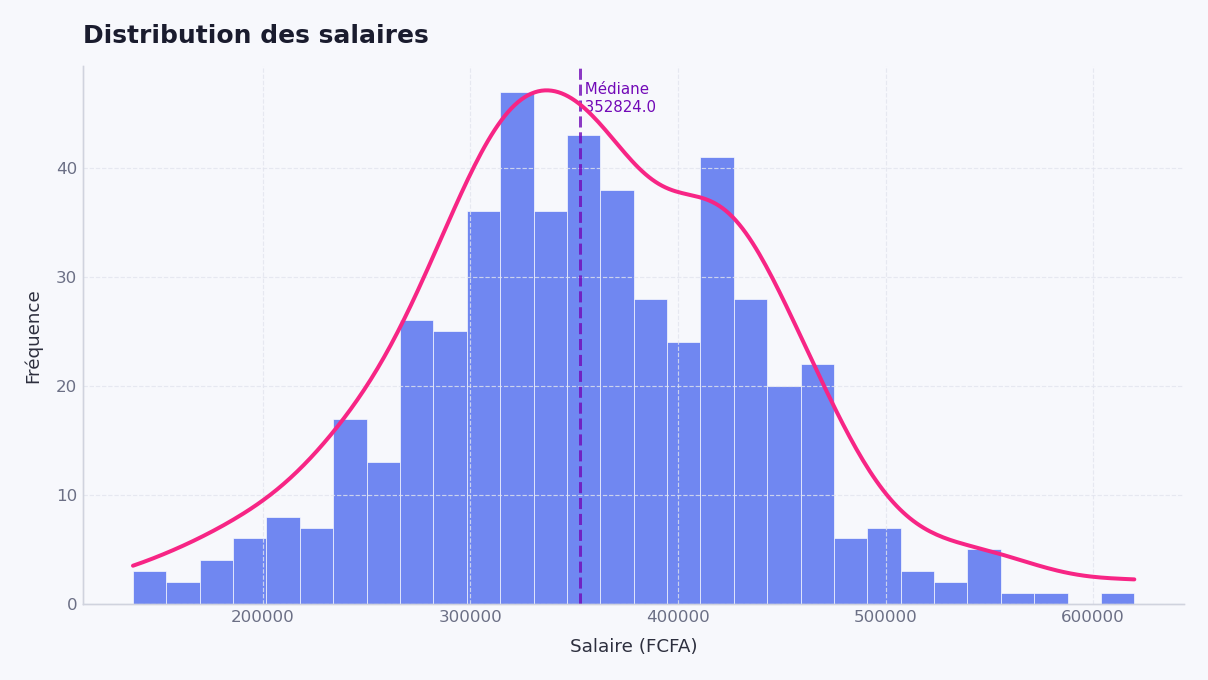

In [92]:
salaires = np.random.normal(350_000, 80_000, 500).clip(min=100_000)
histogramme(
    salaires,
    bins=30,
    titre="Distribution des salaires",
    xlabel="Salaire (FCFA)",
    courbe_densite=True,
)
plt.show()


### `nuage()`

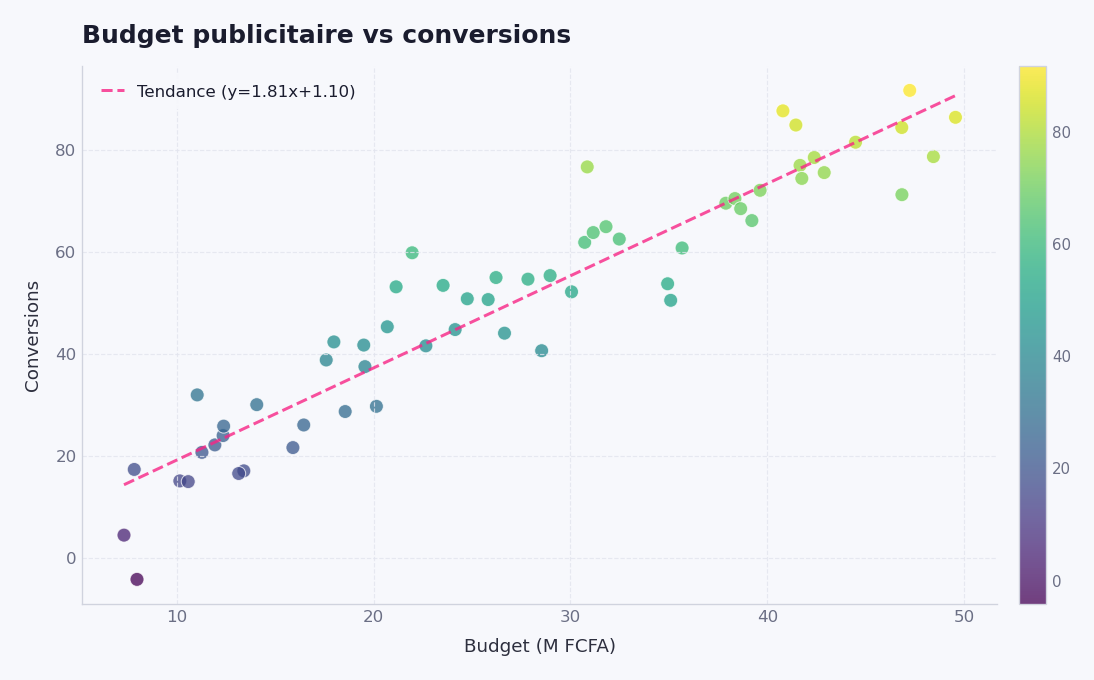

In [94]:
budget_pub = np.random.uniform(5, 50, 60)
conversions = budget_pub * 1.8 + np.random.normal(0, 8, 60)
nuage(
    budget_pub, conversions,
    couleur_var=conversions,
    titre="Budget publicitaire vs conversions",
    xlabel="Budget (M FCFA)", ylabel="Conversions",
    ligne_tendance=True,
)
plt.show()


### `camembert()`

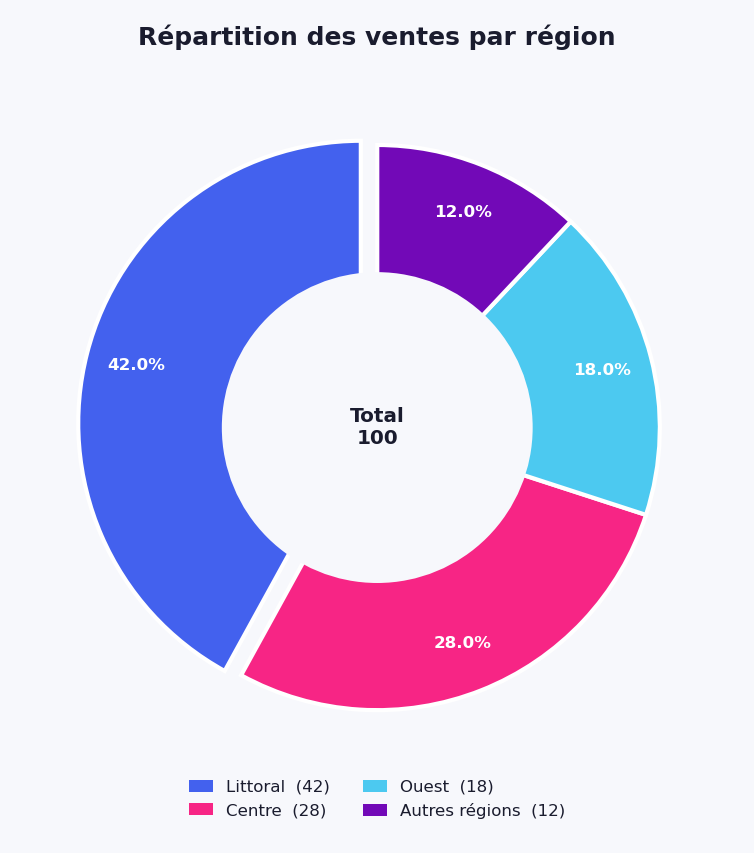

In [97]:
camembert(
    labels=["Littoral", "Centre", "Ouest", "Autres régions"],
    valeurs=[42, 28, 18, 12],
    titre="Répartition des ventes par région",
    donut=True,
)
plt.show()


### `heatmap()`

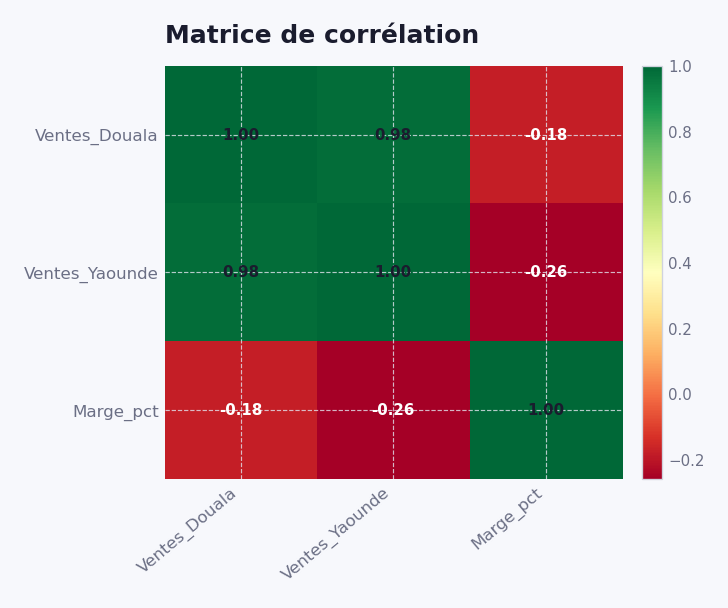

In [99]:
cols = ["Ventes_Douala", "Ventes_Yaounde", "Marge_pct"]
heatmap(
    df[cols].corr().values,
    labels_lignes=cols, labels_colonnes=cols,
    titre="Matrice de corrélation",
)
plt.show()


### `dashboard()`

Grille de graphiques dans une seule figure — construite directement via `GridSpec`,
sans copie d'artistes entre figures.

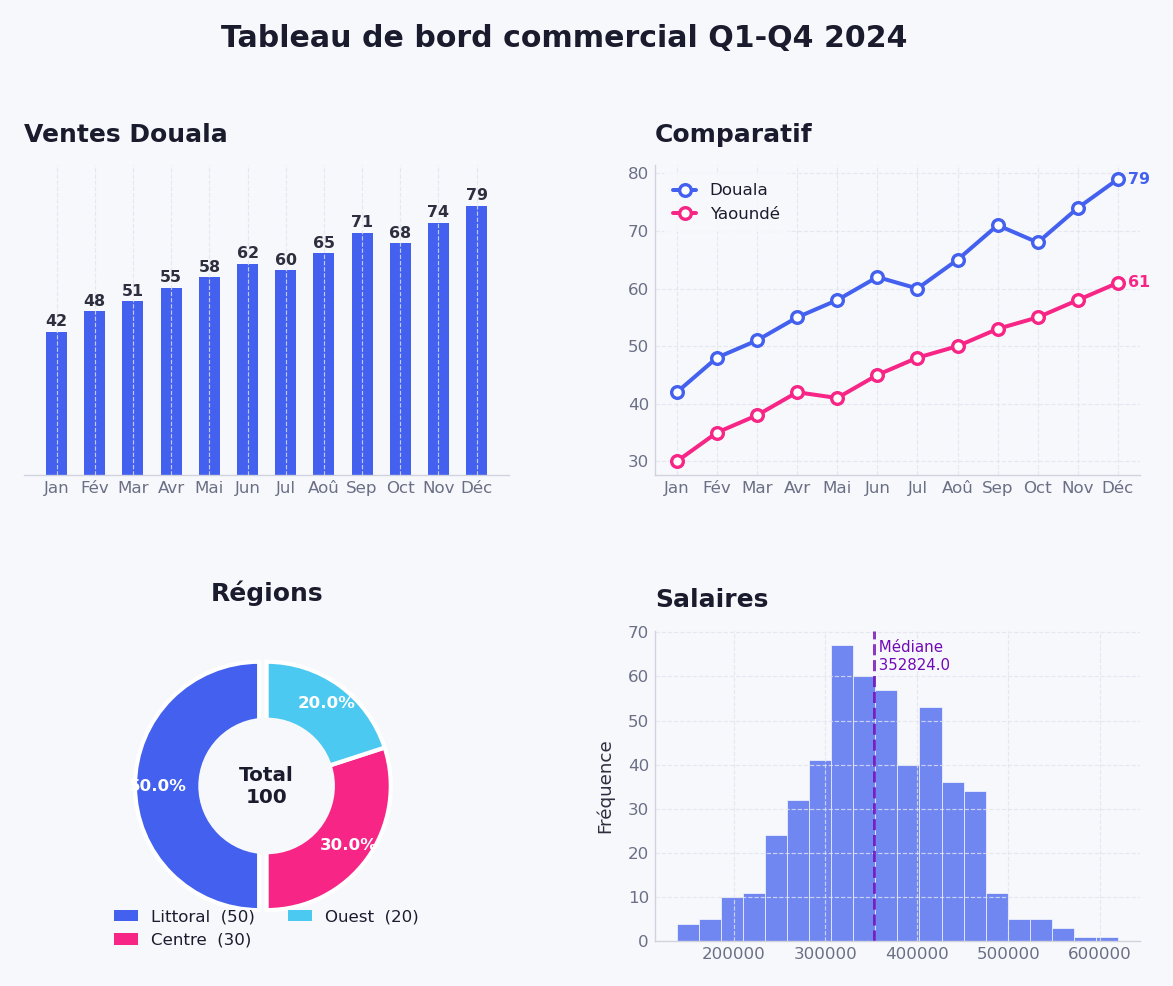

In [101]:
dashboard([
    {"type": "barres", "categories": mois, "valeurs": ventes_douala, "titre": "Ventes Douala"},
    {"type": "ligne", "x": mois, "y_series": {"Douala": ventes_douala, "Yaoundé": ventes_yaounde}, "titre": "Comparatif"},
    {"type": "camembert", "labels": ["Littoral", "Centre", "Ouest"], "valeurs": [50, 30, 20], "titre": "Régions"},
    {"type": "histogramme", "data": salaires, "titre": "Salaires"},
], titre_global="Tableau de bord commercial Q1-Q4 2024", ncols=2)
plt.show()


### Tracer dans un axe existant — `ax=...`

Toutes les fonctions ci-dessus acceptent un paramètre optionnel `ax`. Utile pour composer
plusieurs graphiques `beau_graphique` dans une figure matplotlib que vous contrôlez vous-même.

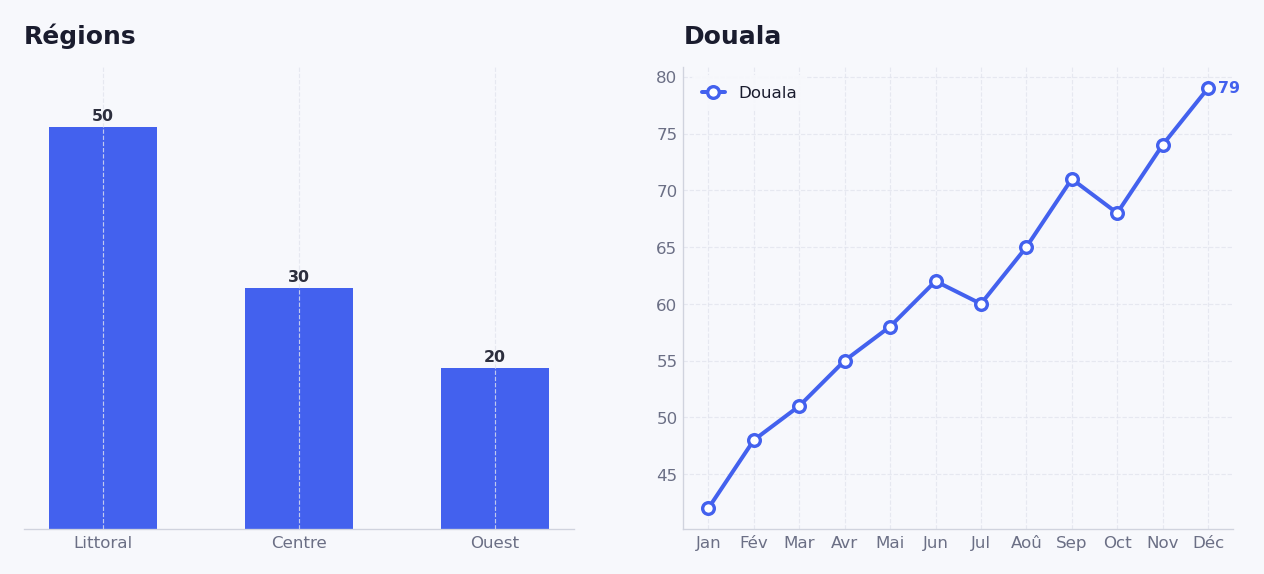

In [103]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
barres(["Littoral", "Centre", "Ouest"], [50, 30, 20], ax=axes[0], titre="Régions")
ligne(mois, {"Douala": ventes_douala}, ax=axes[1], titre="Douala")
plt.show()


### Dates automatiques sur l'axe X

Quand `x` contient des dates réelles (`datetime`, `pandas.Timestamp`...), l'axe est formaté
automatiquement (labels lisibles + rotation). Les libellés textuels (`"Jan"`, `"T1"`) restent
traités comme des catégories — aucun parsing de chaîne n'est tenté.

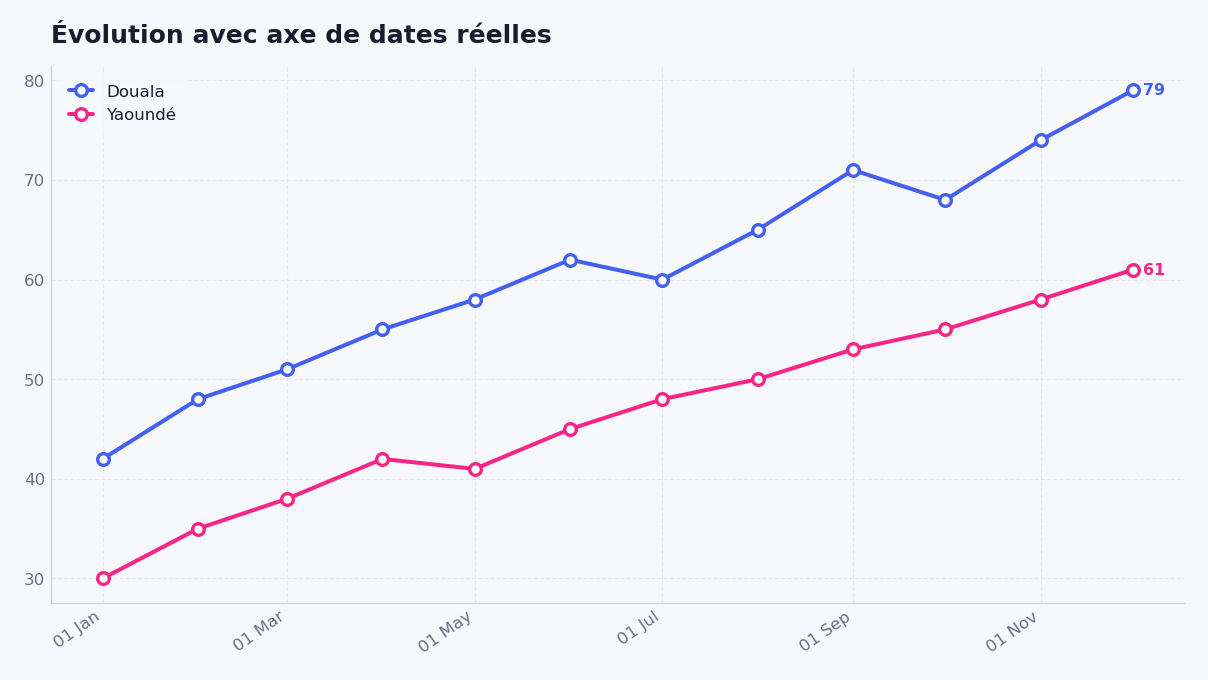

In [109]:
ligne(
    x=df["Date"].tolist(),
    y_series={"Douala": ventes_douala, "Yaoundé": ventes_yaounde},
    titre="Évolution avec axe de dates réelles",
)
plt.show()


### Graphiques McKinsey

Quatre graphiques inspirés des publications McKinsey : comparaison multi-dimensions entre deux périodes, scatter à 4 variables, proportions/ratios en carrés, et barres chronologiques connectées (`barres_connectees()`, présentée en section 3 — elle vit dans `narratif.py`).

### `dot_plot_comparatif()`

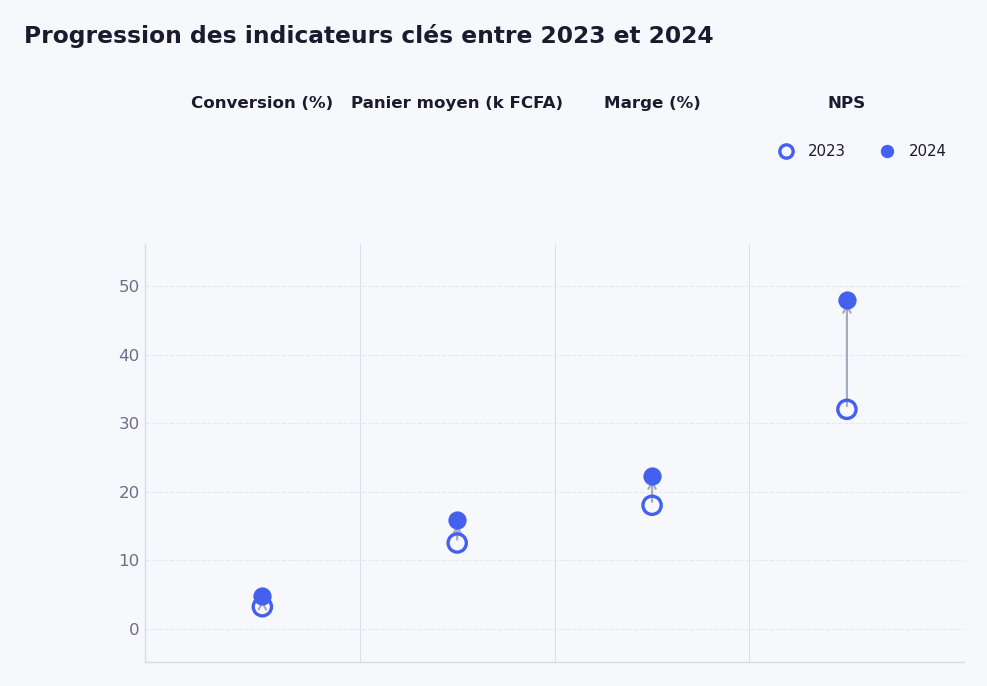

In [114]:
dot_plot_comparatif(
    colonnes={
        "Conversion (%)": (3.2, 4.7),
        "Panier moyen (k FCFA)": (12.5, 15.8),
        "Marge (%)": (18.0, 22.3),
        "NPS": (32, 48),
    },
    label_avant="2023", label_apres="2024",
    titre="Progression des indicateurs clés entre 2023 et 2024",
)
plt.show()

### `bulle_4d()`

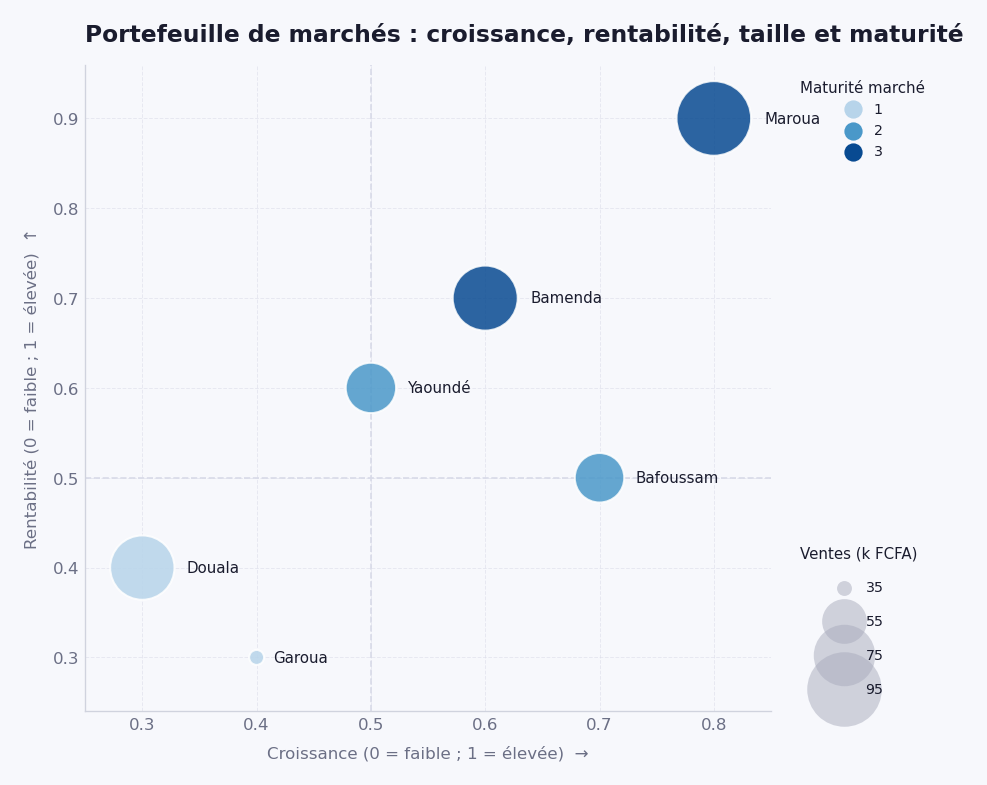

In [119]:
bulle_4d(
    x=[0.3, 0.5, 0.7, 0.4, 0.6, 0.8],
    y=[0.4, 0.6, 0.5, 0.3, 0.7, 0.9],
    taille=[ventes_douala[-1], ventes_yaounde[-1], 60, 35, 80, 95],
    couleur_var=[1, 2, 2, 1, 3, 3],
    labels=["Douala", "Yaoundé", "Bafoussam", "Garoua", "Bamenda", "Maroua"],
    xlabel="Croissance (0 = faible ; 1 = élevée)",
    ylabel="Rentabilité (0 = faible ; 1 = élevée)",
    label_taille="Ventes (k FCFA)",
    label_couleur="Maturité marché",
    quadrants=True,
    titre="Portefeuille de marchés : croissance, rentabilité, taille et maturité",
)
plt.show()

### `unit_chart()`

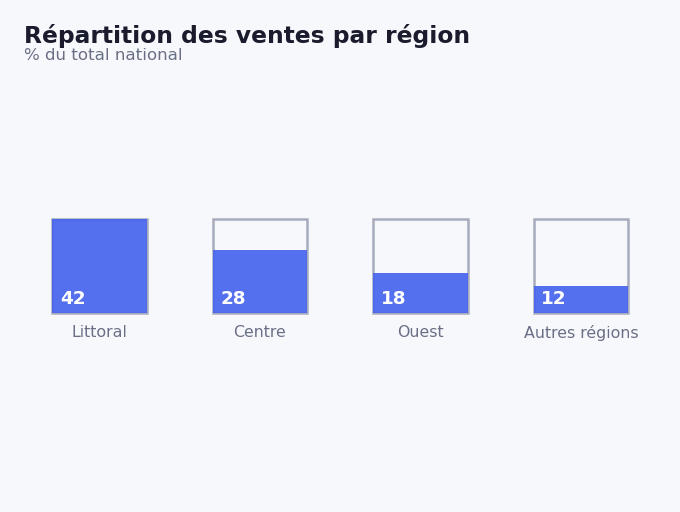

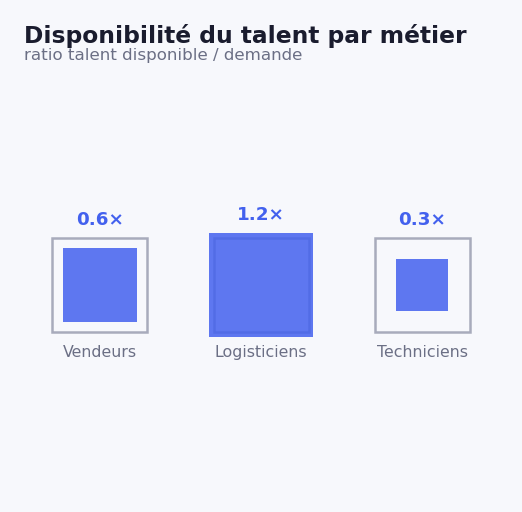

In [121]:
unit_chart(
    categories=["Littoral", "Centre", "Ouest", "Autres régions"],
    valeurs=[42, 28, 18, 12],
    mode="proportion",
    titre="Répartition des ventes par région",
    sous_titre="% du total national",
)
plt.show()

unit_chart(
    categories=["Vendeurs", "Logisticiens", "Techniciens"],
    valeurs=[0.6, 1.2, 0.3],
    mode="ratio",
    titre="Disponibilité du talent par métier",
    sous_titre="ratio talent disponible / demande",
)
plt.show()

### Nouveaux types (Phase 2) — distributions, contributions, comparaisons

Voir [`GUIDE_CHOIX.md`](GUIDE_CHOIX.md) pour savoir laquelle de ces fonctions choisir selon le message à transmettre.

### `box_plot()` et `violin()`

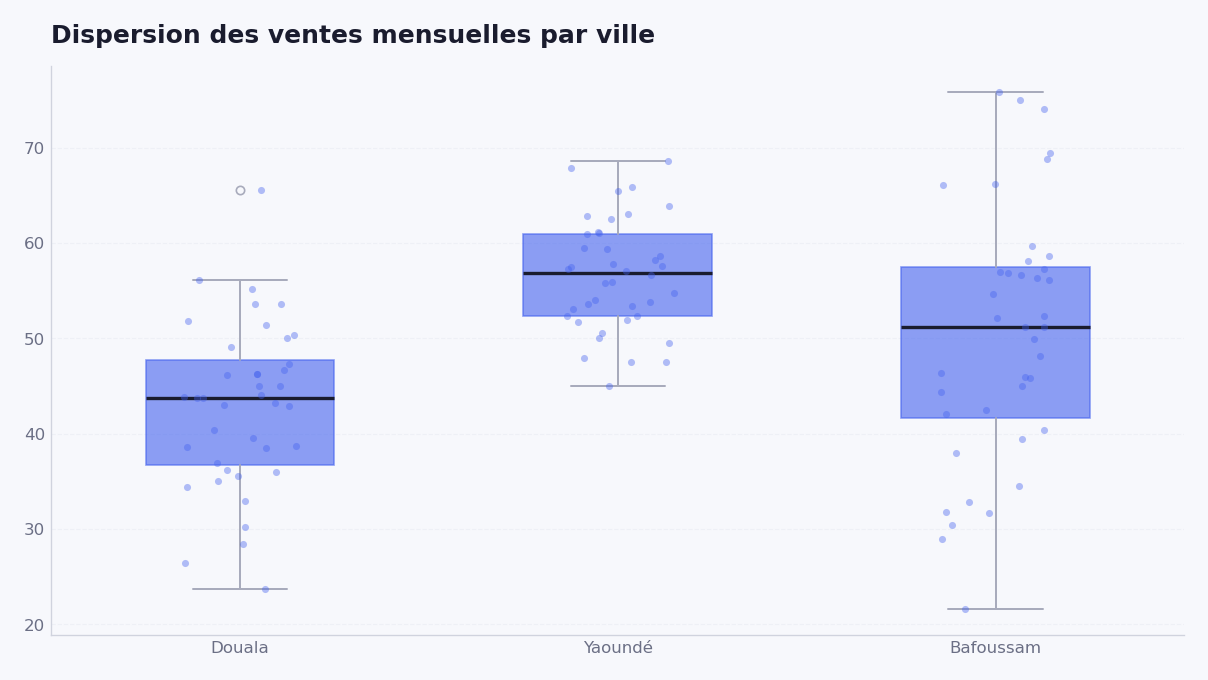

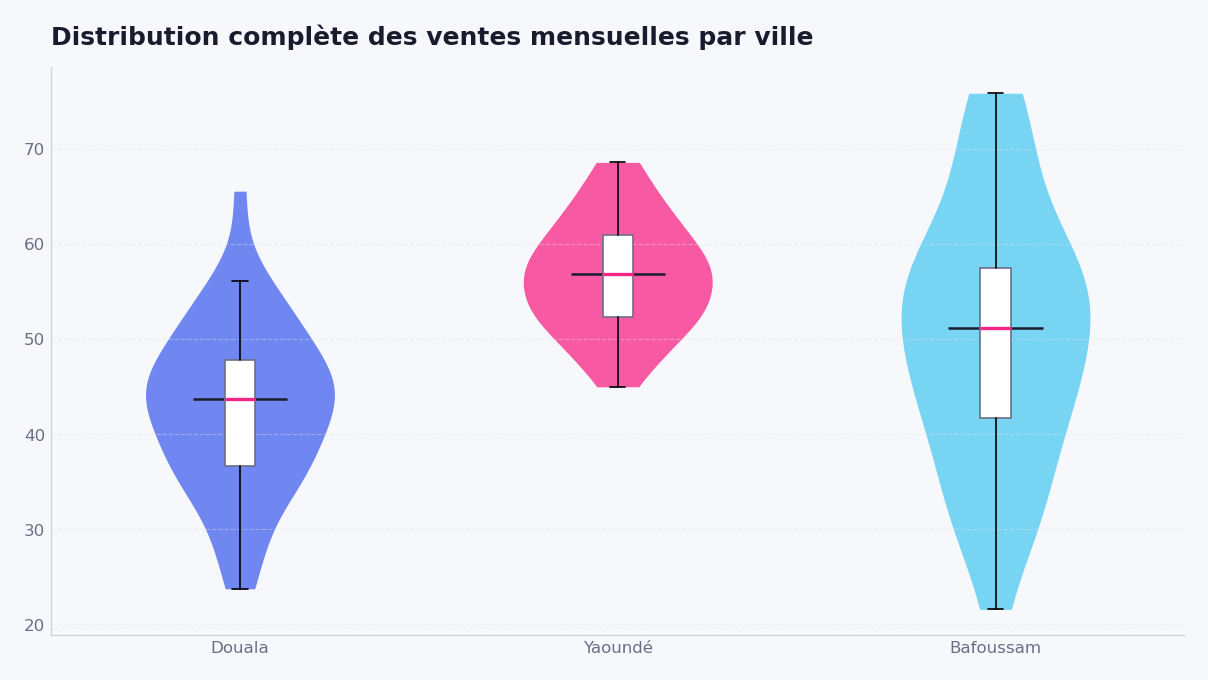

In [125]:
echantillons = [
    np.random.normal(45, 8, 40),
    np.random.normal(58, 6, 40),
    np.random.normal(50, 12, 40),
]
villes = ["Douala", "Yaoundé", "Bafoussam"]

box_plot(
    data=echantillons,
    categories=villes,
    afficher_points=True,
    titre="Dispersion des ventes mensuelles par ville",
)
plt.show()

violin(
    data=echantillons,
    categories=villes,
    titre="Distribution complète des ventes mensuelles par ville",
)
plt.show()

### `waterfall()`

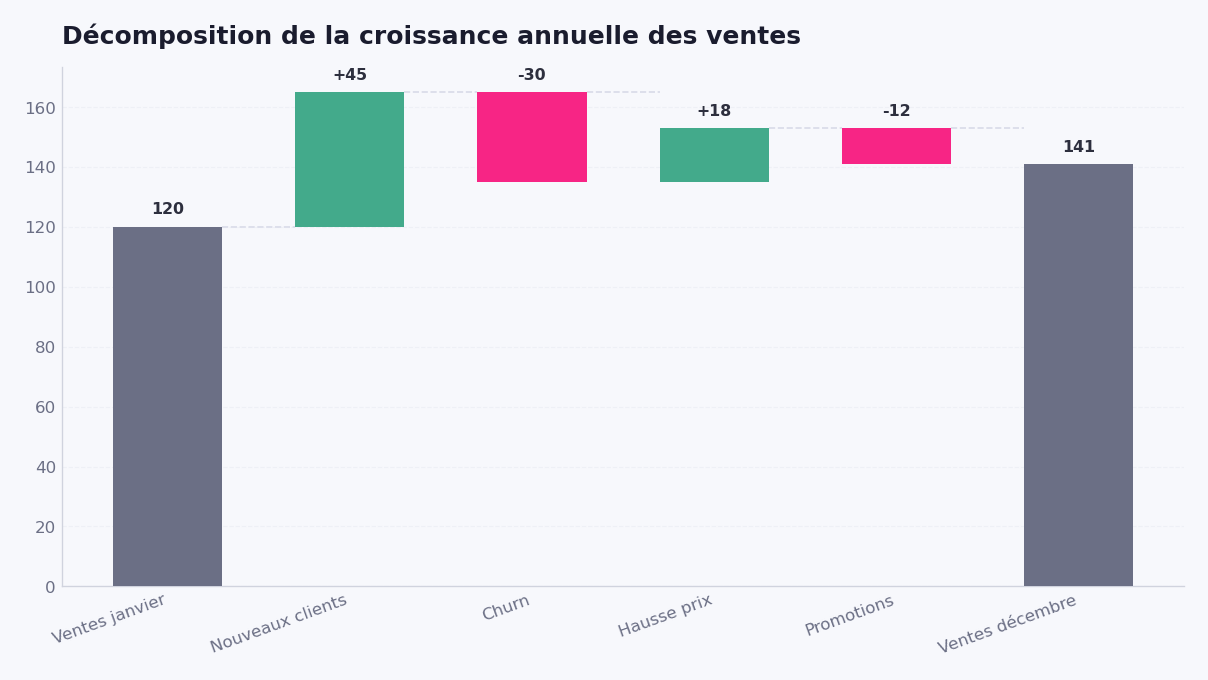

In [128]:
waterfall(
    categories=["Nouveaux clients", "Churn", "Hausse prix", "Promotions"],
    valeurs=[45, -30, 18, -12],
    total_debut=120,
    label_debut="Ventes janvier",
    label_fin="Ventes décembre",
    titre="Décomposition de la croissance annuelle des ventes",
)
plt.show()

### `lollipop()`

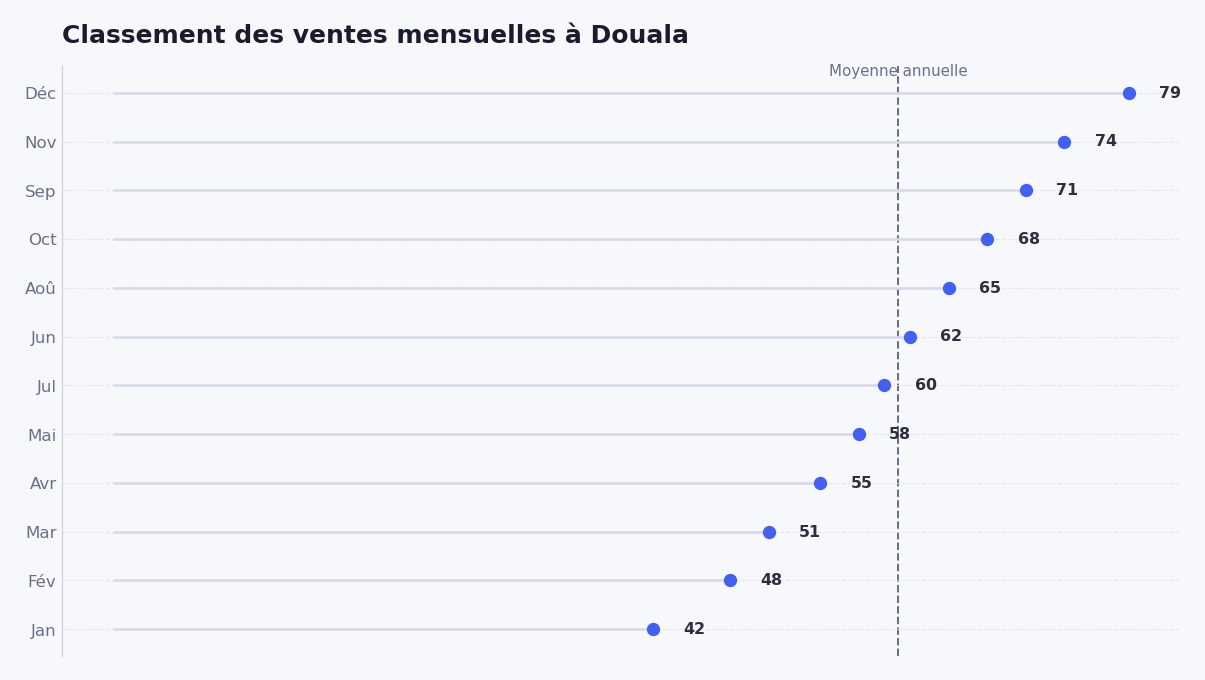

In [130]:
lollipop(
    categories=mois,
    valeurs=ventes_douala,
    ligne_ref=float(np.mean(ventes_douala)),
    label_ref="Moyenne annuelle",
    titre="Classement des ventes mensuelles à Douala",
)
plt.show()

### `slope()`

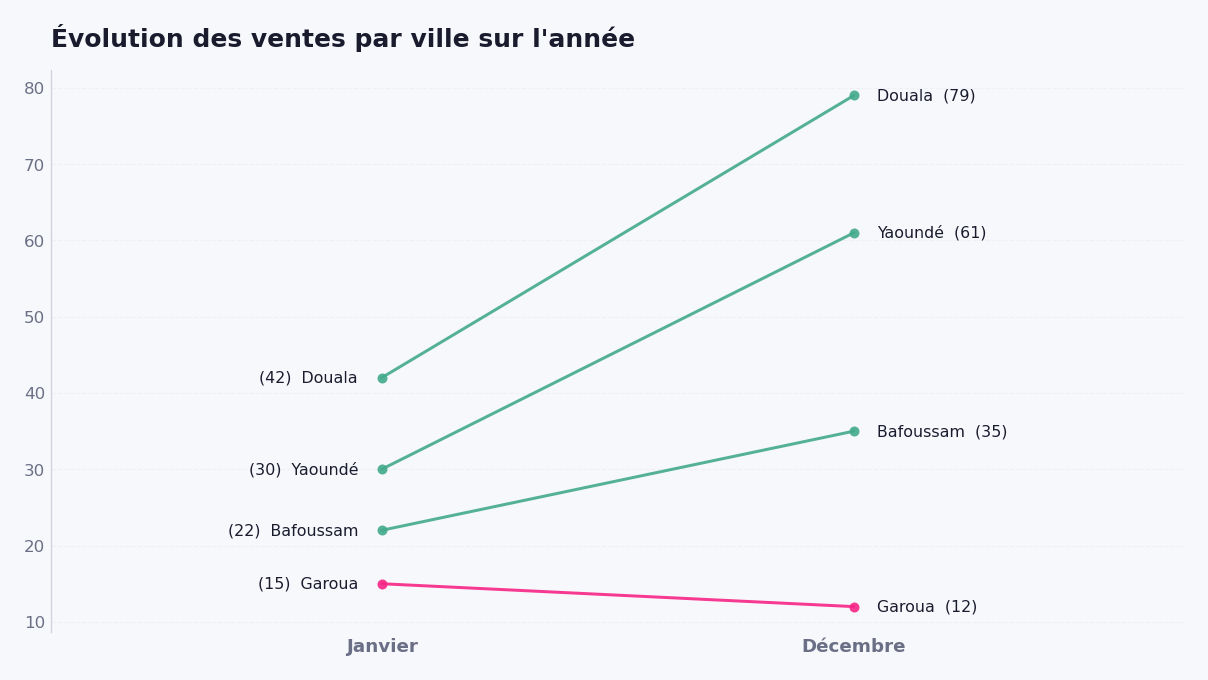

In [132]:
slope(
    categories=["Douala", "Yaoundé", "Bafoussam", "Garoua"],
    valeurs_gauche=[42, 30, 22, 15],
    valeurs_droite=[79, 61, 35, 12],
    label_gauche="Janvier", label_droite="Décembre",
    titre="Évolution des ventes par ville sur l\'année",
)
plt.show()

### `facet()`

C:\Users\jean luc\Documents\orange\beau_viz\src\beau_graphique\beau_graphique.py:1467: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


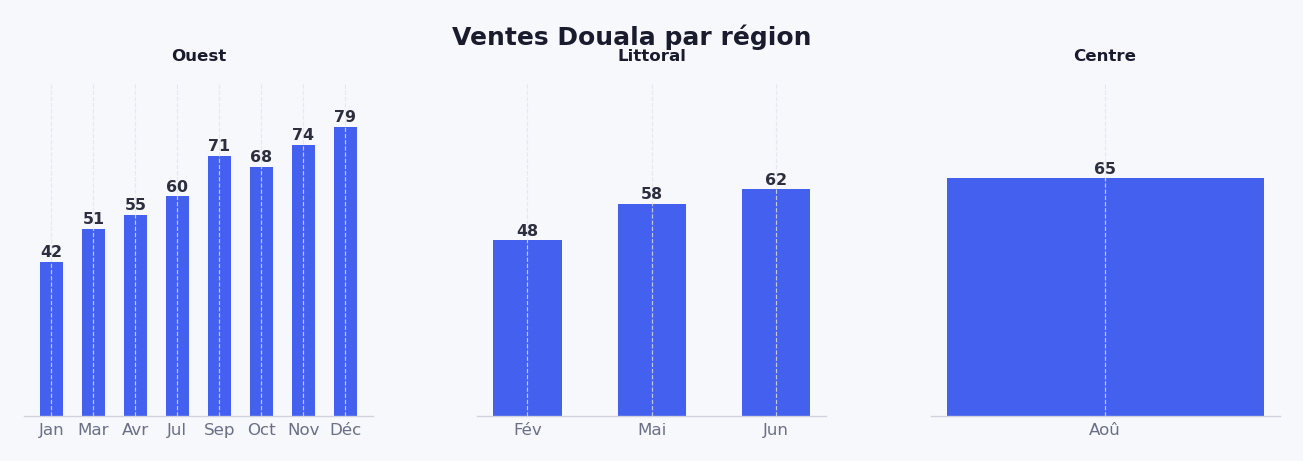

In [134]:
facet(
    df,
    x="Mois", y="Ventes_Douala", par="Region",
    type_graphique="barres",
    titre="Ventes Douala par région",
)
plt.show()

## 3. `narratif.py` — hiérarchie visuelle & annotations

### `barres_focus()`

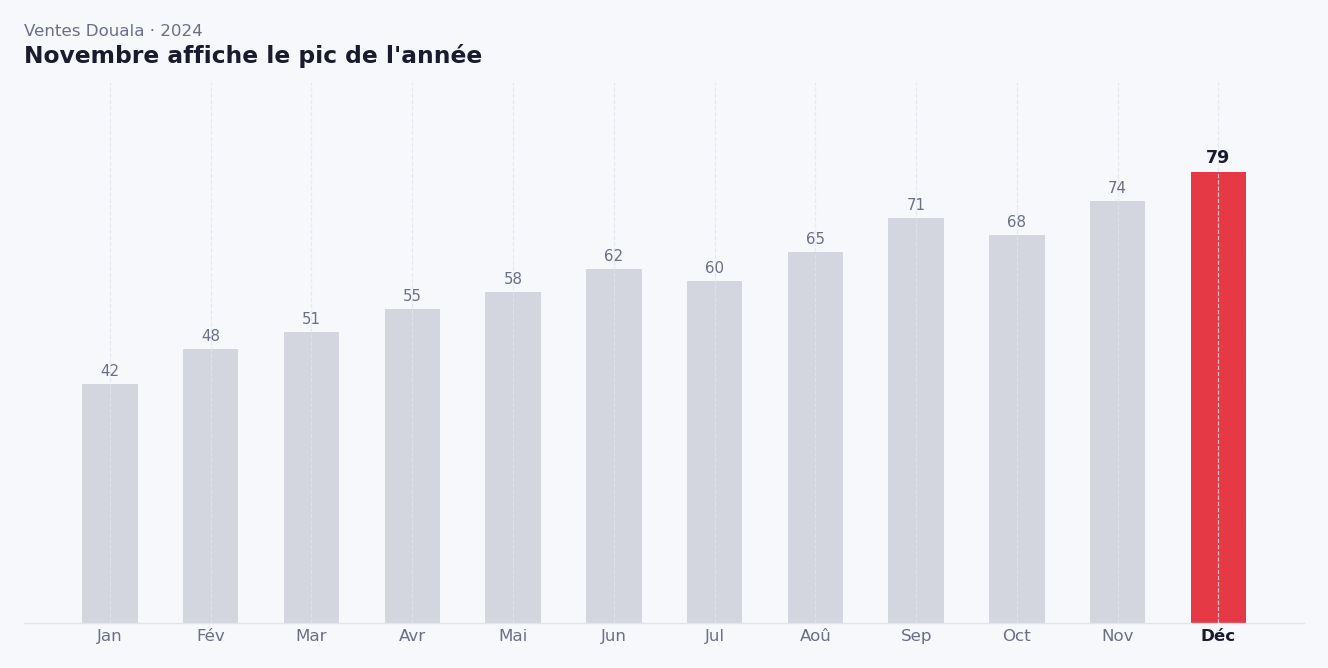

In [136]:
fig, ax = barres_focus(
    categories=mois,
    valeurs=ventes_douala,
    focus=int(np.argmax(ventes_douala)),
    titre="Novembre affiche le pic de l'année",
    sous_titre="Ventes Douala · 2024",
    accent=ACCENTS["rouge"],
)
plt.show()


### `ligne_focus()`

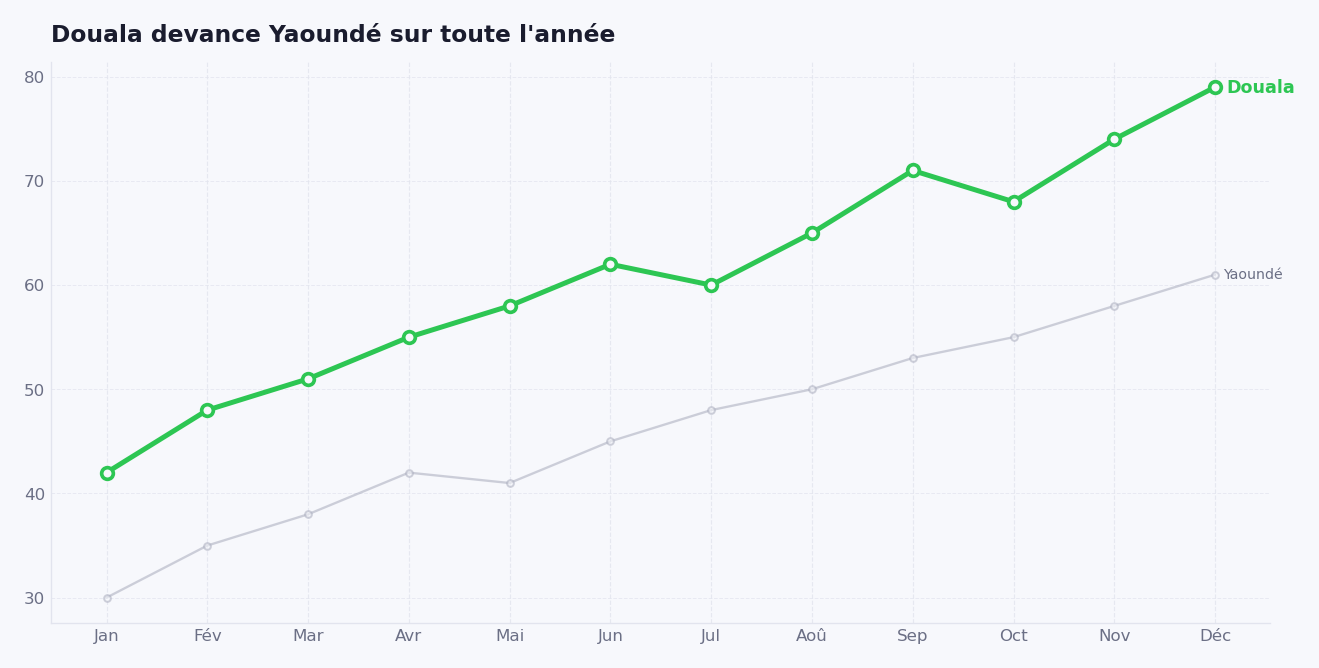

In [139]:
fig, ax = ligne_focus(
    x=mois,
    series={"Douala": ventes_douala, "Yaoundé": ventes_yaounde},
    focus_serie="Douala",
    titre="Douala devance Yaoundé sur toute l'année",
    accent=ACCENTS["vert"],
)
plt.show()


### `comparaison_avant_apres()`

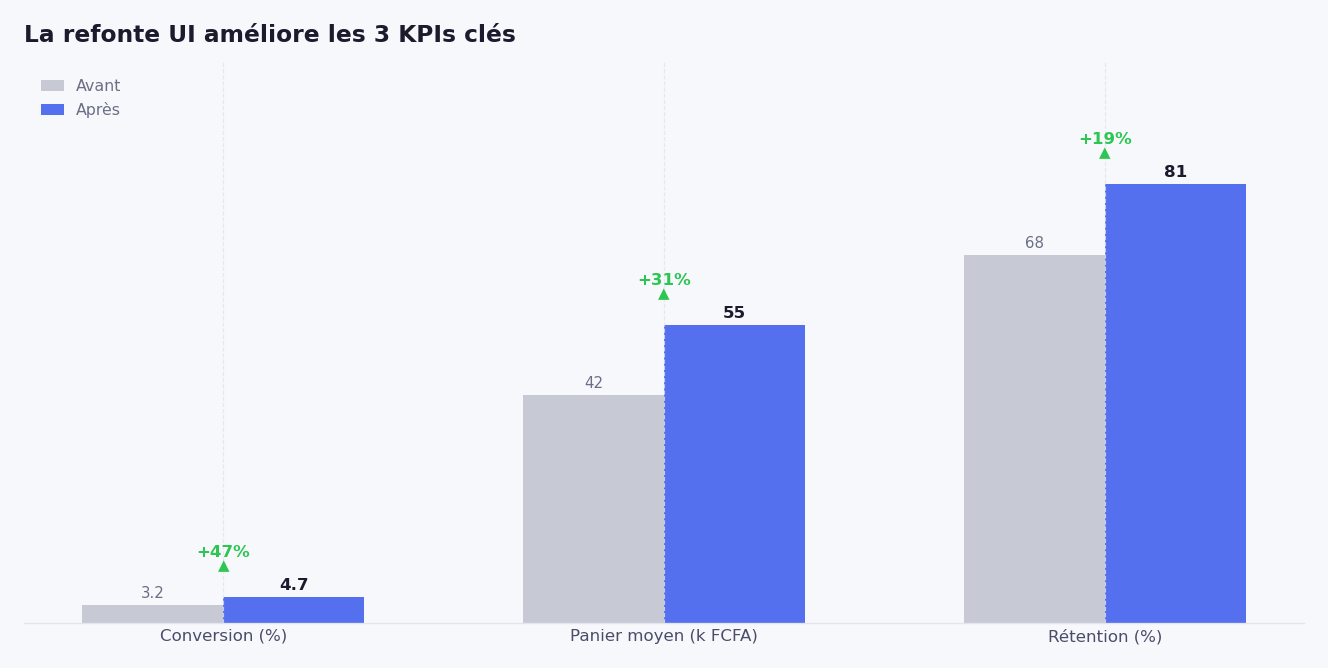

In [142]:
fig, ax = comparaison_avant_apres(
    categories=["Conversion (%)", "Panier moyen (k FCFA)", "Rétention (%)"],
    avant=[3.2, 42, 68],
    apres=[4.7, 55, 81],
    titre="La refonte UI améliore les 3 KPIs clés",
    accent=ACCENTS["bleu"],
)
plt.show()


### `barres_ranked()`

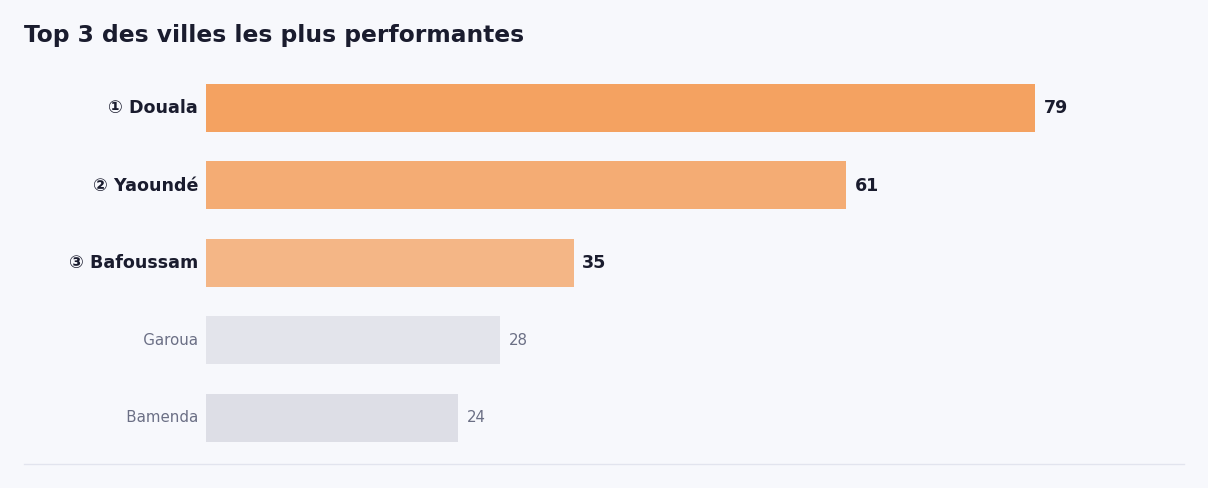

In [145]:
fig, ax = barres_ranked(
    categories=["Douala", "Yaoundé", "Bafoussam", "Garoua", "Bamenda"],
    valeurs=[79, 61, 35, 28, 24],
    titre="Top 3 des villes les plus performantes",
    top_n=3,
    accent=ACCENTS["or"],
)
plt.show()


### `divergent()`

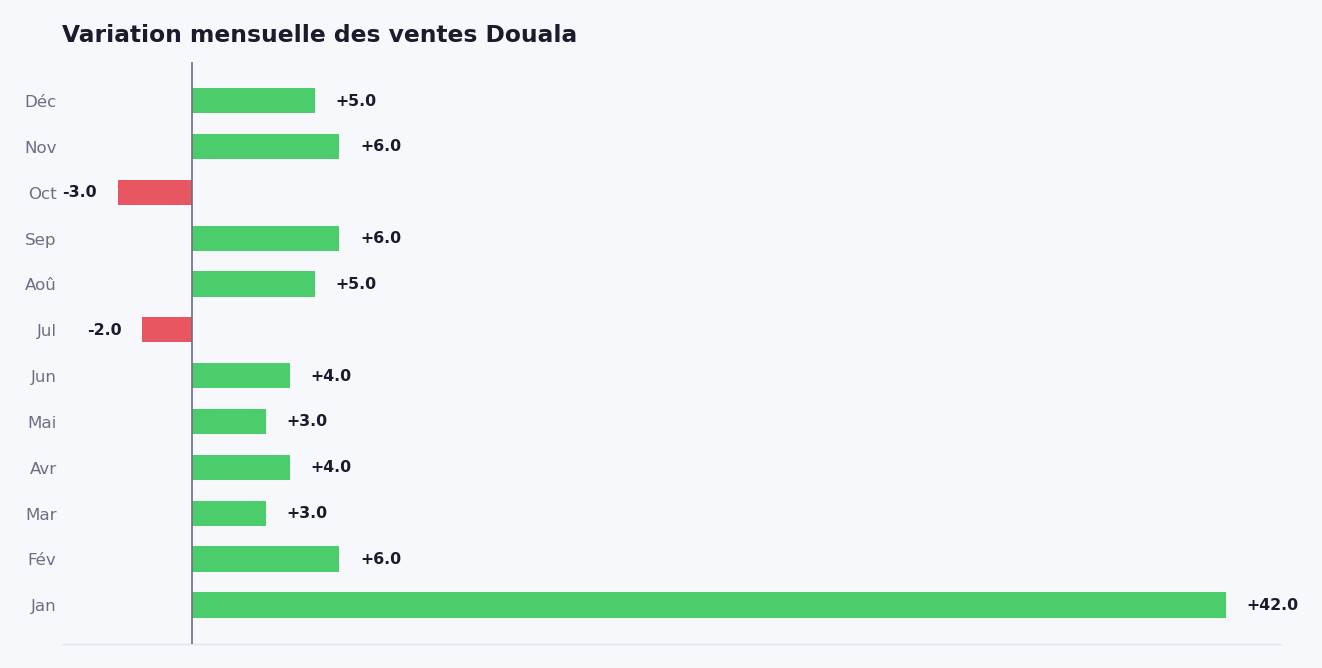

In [148]:
fig, ax = divergent(
    categories=mois,
    valeurs=list(np.diff([0] + ventes_douala)),
    titre="Variation mensuelle des ventes Douala",
)
plt.show()


### `bullet_chart()`

C:\Users\jean luc\Documents\orange\beau_viz\src\beau_graphique\narratif.py:553: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all axes decorations.
  fig.tight_layout(h_pad=0.4)


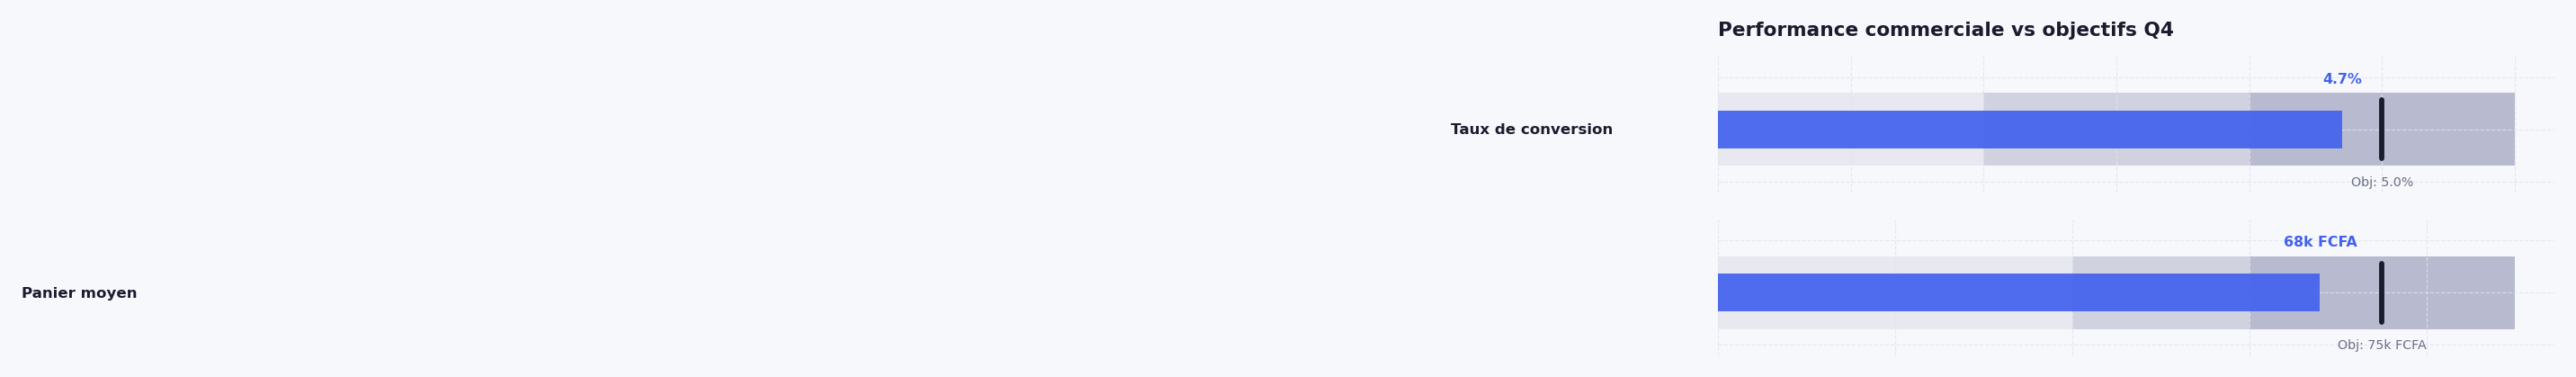

In [151]:
fig, axes = bullet_chart([
    {"nom": "Taux de conversion", "valeur": 4.7, "objectif": 5.0,
     "plages": [2, 4, 6], "fmt": "{:.1f}%"},
    {"nom": "Panier moyen", "valeur": 68, "objectif": 75,
     "plages": [40, 60, 90], "fmt": "{:.0f}k FCFA"},
], titre="Performance commerciale vs objectifs Q4")
plt.show()


### `barres_connectees()`

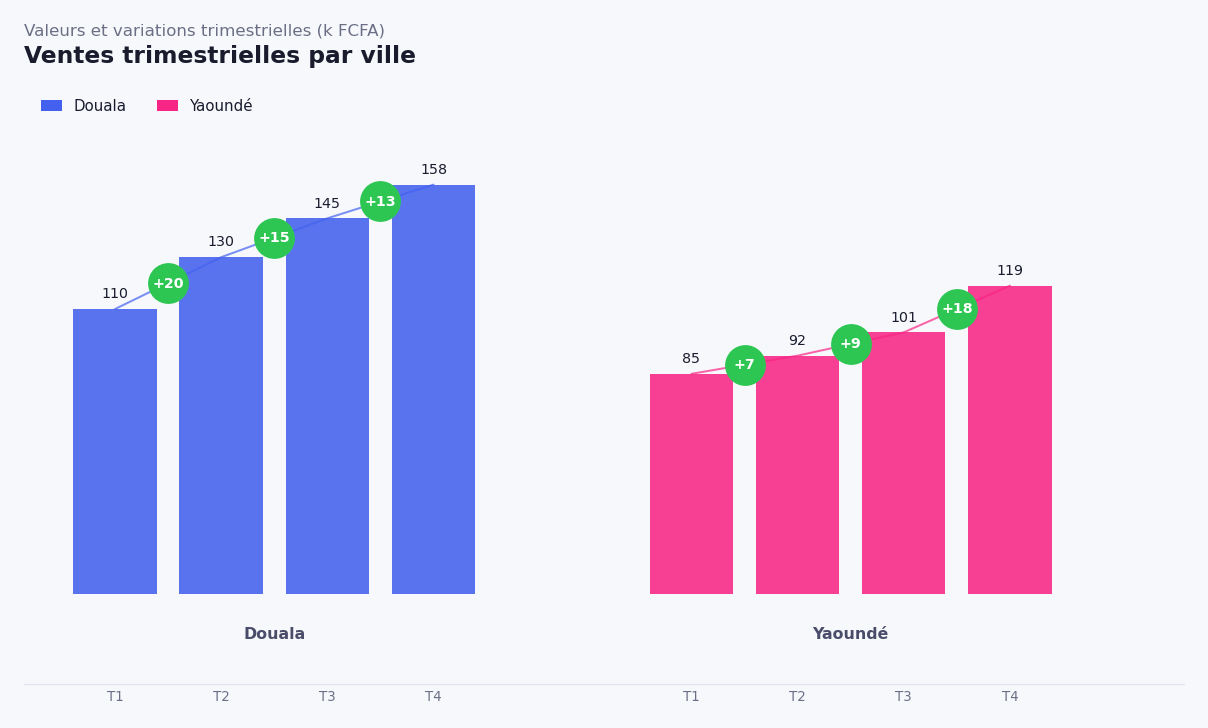

In [154]:
fig, ax = barres_connectees(
    categories=["Douala", "Yaoundé"],
    periodes=["T1", "T2", "T3", "T4"],
    valeurs=[
        [110, 130, 145, 158],
        [85, 92, 101, 119],
    ],
    titre="Ventes trimestrielles par ville",
    sous_titre="Valeurs et variations trimestrielles (k FCFA)",
)
plt.show()

### Annotations superposables

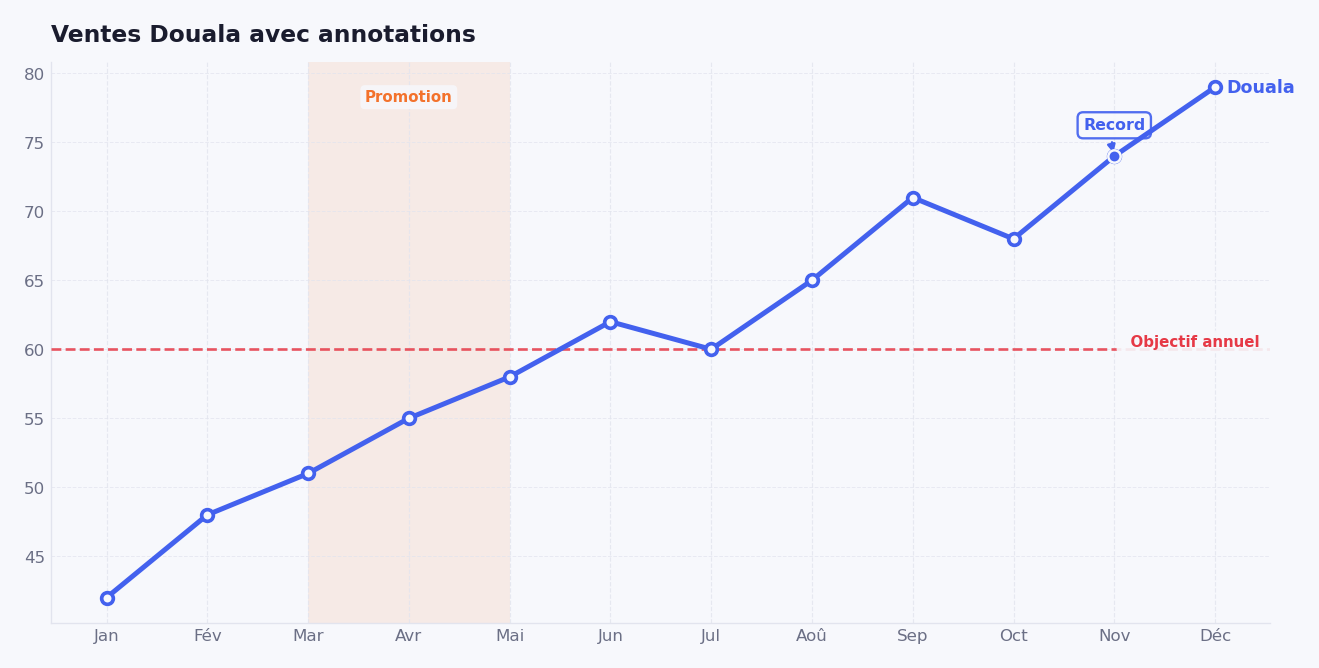

In [157]:
fig, ax = ligne_focus(
    x=mois, series={"Douala": ventes_douala}, focus_serie="Douala",
    titre="Ventes Douala avec annotations",
)
annoter_zone(ax, x_debut=2, x_fin=4, label="Promotion", couleur=ACCENTS["orange"])
annoter_seuil(ax, y=60, label="Objectif annuel")
annoter_point(ax, x=10, y=ventes_douala[10], label="Record", direction="haut")
plt.show()


## 4. `pipeline.py` — intégration DataFrame

### `inspecter()`

In [161]:
inspecter(df)


┌──────────────────────────────────────────────────────────┐
│  DataFrame — 12 lignes × 6 colonnes                      │
├──────────────────────────────────────────────────────────┤
│  Colonne                Type            NaN   Unique Plage / Exemples  │
├──────────────────────────────────────────────────────────┤
│  Mois                   object            —       12  Jan, Fév, Mar     │
│  Date                   datetime64[       —       12  2024-01-01 00:0…  │
│  Ventes_Douala          int64             —       12  42 → 79           │
│  Ventes_Yaounde         int64             —       12  30 → 61           │
│  Region                 object            —        3  Ouest, Littoral…  │
│  Marge_pct              float64           —       11  11.50 → 26.00      ⚡1│
├──────────────────────────────────────────────────────────┤
│  ✓ Complétude : 100.0%   NaN total : 0   Doublons : 0          │
│  Num : 3 col(s)   Cat : 3 col(s)                              │
└───────────────────────────

### `nettoyer()`

In [164]:
df_avec_nan = df.copy()
df_avec_nan.loc[2, "Marge_pct"] = np.nan
df_propre = nettoyer(df_avec_nan, dropna="fill", dedup=True, trier_par="Mois")


✓ nettoyer() — 12 lignes × 6 colonnes
  · NaN 'Marge_pct' → médiane (19.90) ×1
  · trié par 'Mois'


### `depuis_df()` + wrappers `_df`

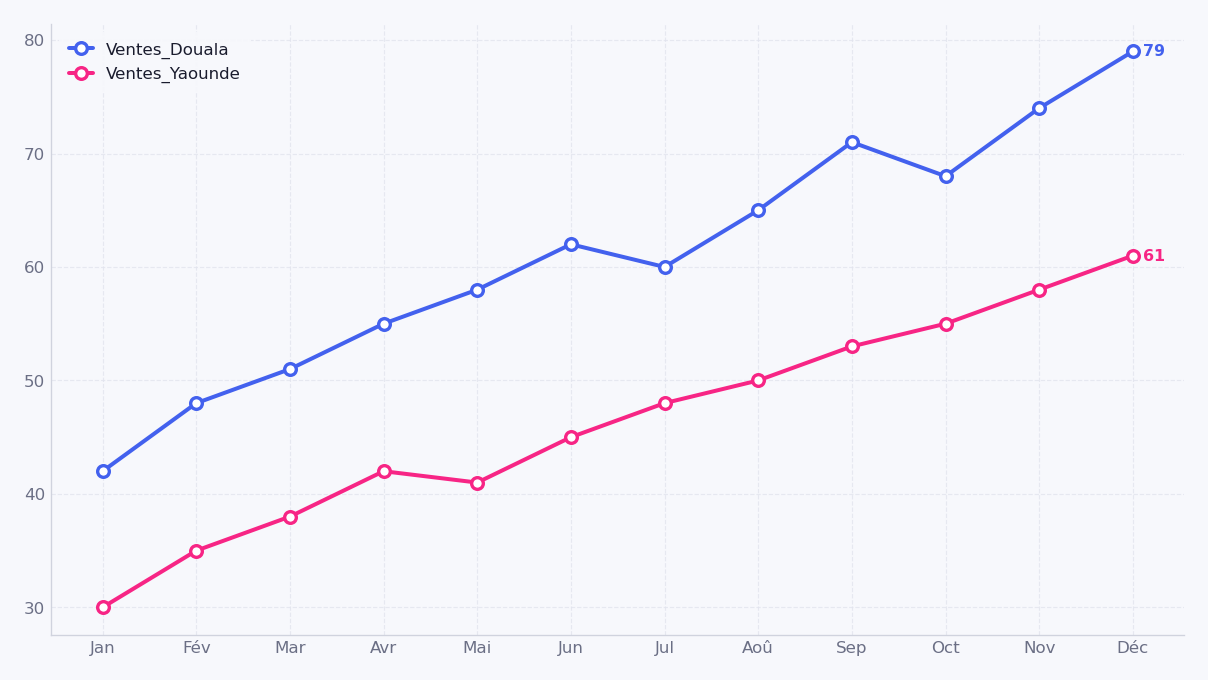

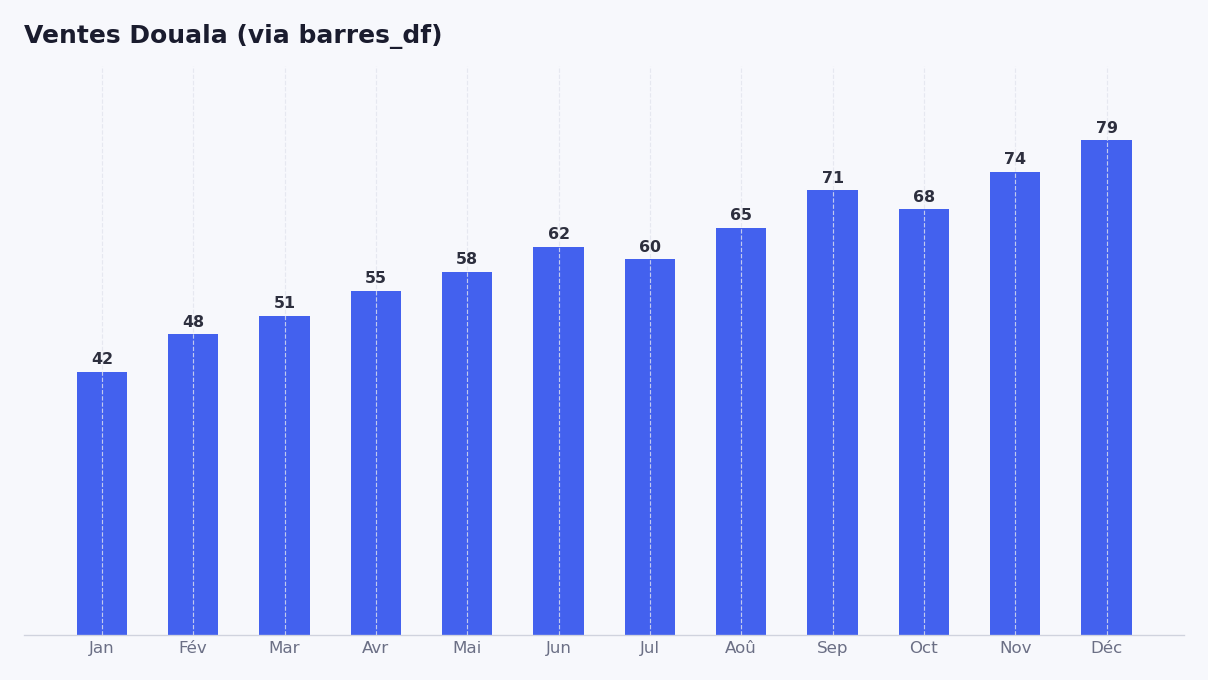

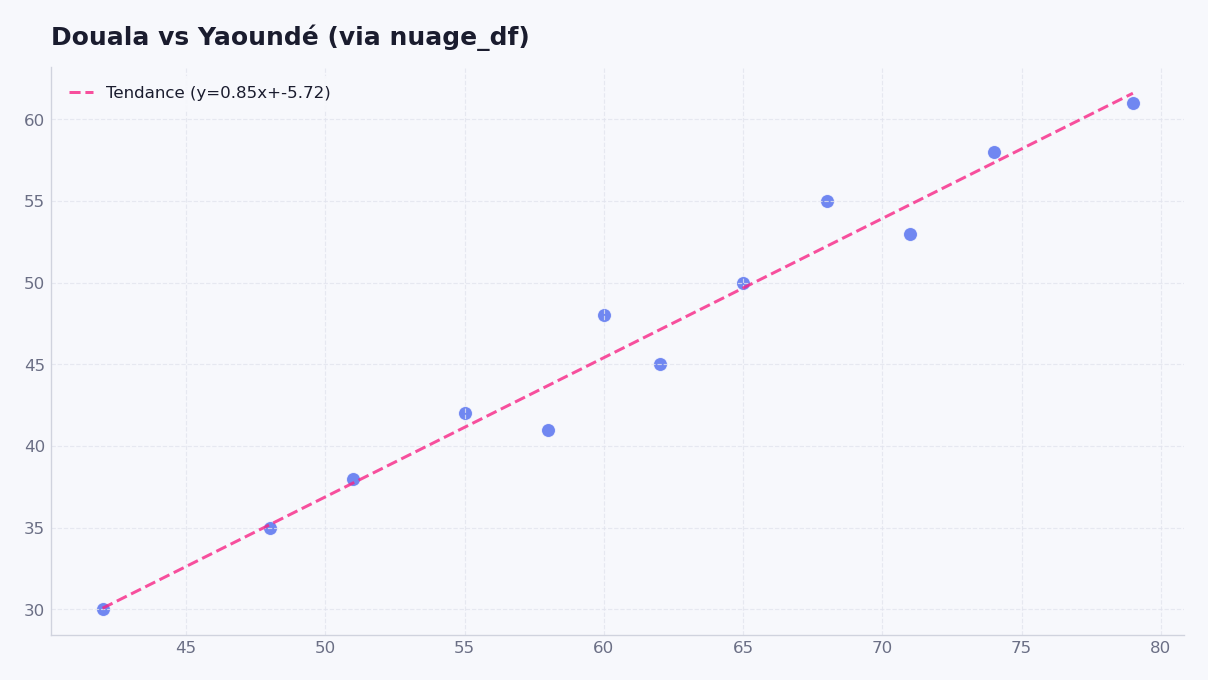

In [167]:
ligne(**depuis_df(df, x="Mois", y=["Ventes_Douala", "Ventes_Yaounde"]))
plt.show()

barres_df(df, x="Mois", y="Ventes_Douala", titre="Ventes Douala (via barres_df)")
plt.show()

nuage_df(df, x="Ventes_Douala", y="Ventes_Yaounde", ligne_tendance=True,
         titre="Douala vs Yaoundé (via nuage_df)")
plt.show()


## 5. `themes.py` — thèmes et palettes

In [170]:
lister()


┌────────────────────────────────────────────────────────────┐
│  Thèmes disponibles                                        │
├────────────────────────────────────────────────────────────┤
│  defaut                 Palette bleue-rose vive, fond  ◀ actif│
│  finance                Palette sobre et professionnel        │
│  sante                  Teintes médicales claires — bl        │
│  academique             Sobre pour publications — 8 co        │
│  tech                   Néon contrôlé sur fond sombre         │
│  minimal                Gris + 1 accent — pour rapport        │
│  chaud                  Tonalités ambre et corail — sl        │
│  sombre                 Fond noir profond, palette viv        │
│  daltonisme_safe        Palette Wong (2011) — distingu        │
│  deuteranopie           Optimisée rouge-vert (8 % des         │
│  sequentielle_bleu      Dégradé clair→foncé pour une v        │
│  divergente             Rouge → blanc → bleu — pour de        │
└──────────────────

✓ Thème 'Finance' activé ☀


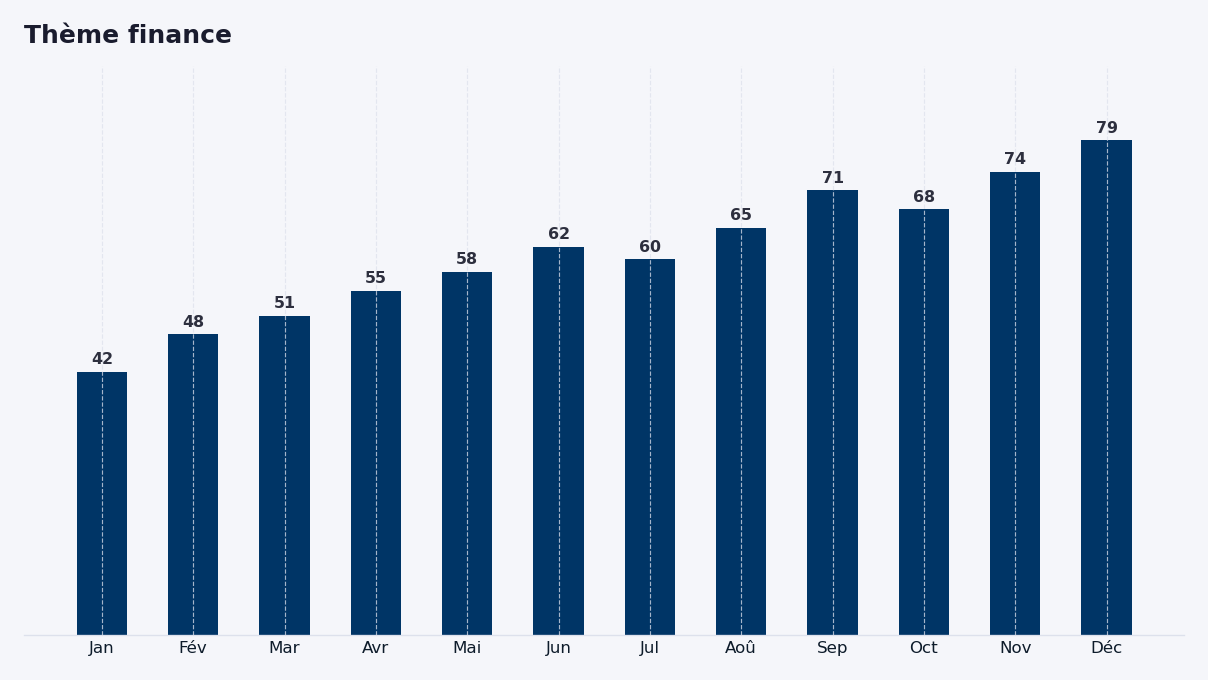

✓ Thème 'Sombre' activé 🌙


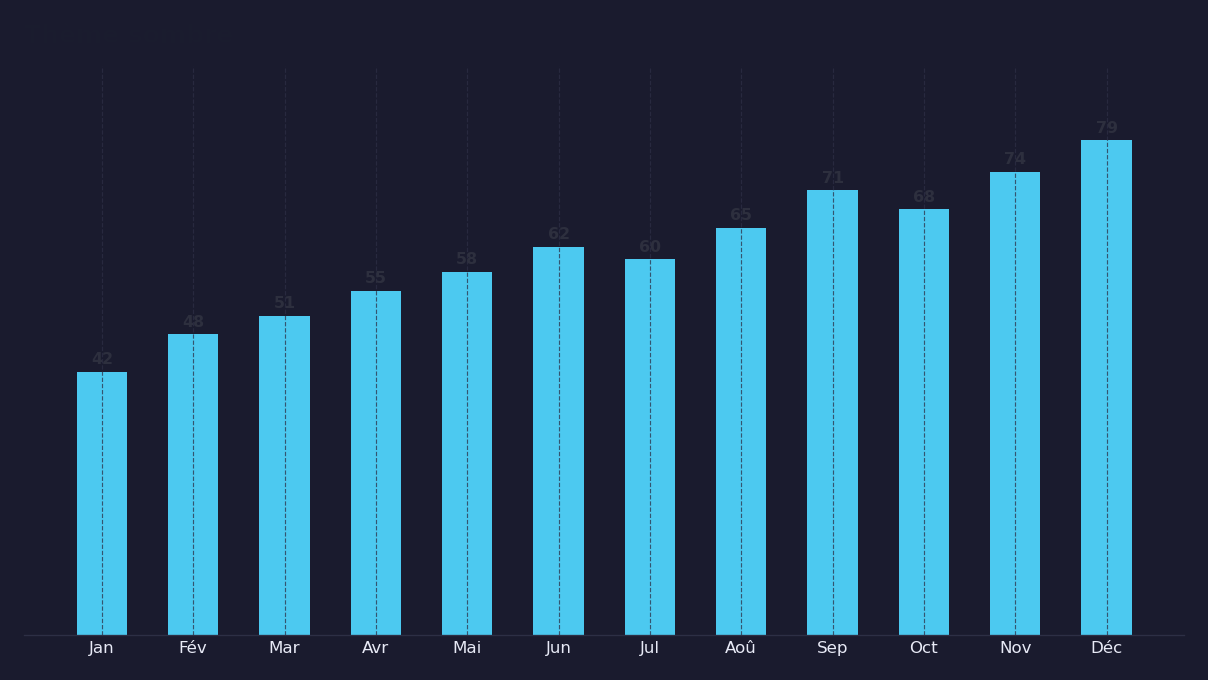

✓ Thème 'Défaut' activé ☀


In [172]:
appliquer("finance")
barres(mois, ventes_douala, titre="Thème finance")
plt.show()

appliquer("sombre")
barres(mois, ventes_douala, titre="Thème sombre")
plt.show()

reinitialiser()


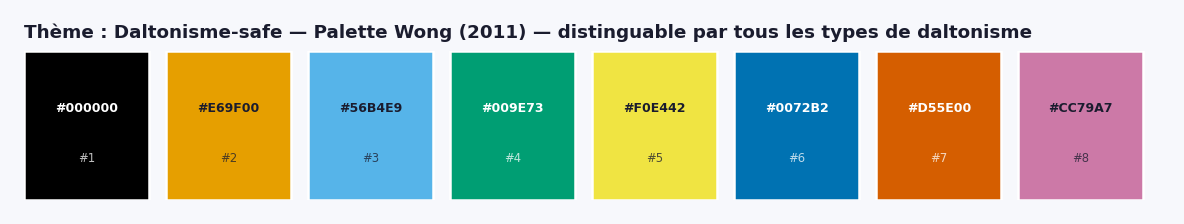

In [35]:
apercu("daltonisme_safe")
plt.show()
